<a href="https://colab.research.google.com/github/NikhilBsc/BscTraining/blob/main/RAG(24_07_2026).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# practical on RNN

In [2]:
!pip install -q tensorflow

In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb

In [4]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

In [5]:
from tensorflow.keras.layers import Embedding,SimpleRNN,Dense
import matplotlib.pyplot as plt

#load and understand hte dataset

In [6]:
from re import X
vocab_size = 10000
(X_train,y_train),(X_test,y_test) = imdb.load_data(num_words=vocab_size)

print("Training Samples :",len(X_train))
print("testing samples",len(X_test))

print(X_train[0])
print("label:",y_train[0])

Training Samples : 25000
testing samples 25000
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
label: 1


#padding th eswquence

In [7]:
max_length =200

X_train = pad_sequences(X_train,maxlen=max_length,padding ='post')
X_test = pad_sequences(X_test,maxlen=max_length , padding ='post')

print("training shape :",X_train.shape)
print("testing shape :",X_test.shape)

training shape : (25000, 200)
testing shape : (25000, 200)


#build the RNN Model Architecture

In [8]:
model = Sequential()
model.add(Embedding(input_dim=vocab_size,output_dim=64,input_length=max_length))
model.add(SimpleRNN(64))
model.add(Dense(1,activation ='sigmoid'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#Compile and train the model

In [9]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

history = model.fit(X_train,y_train,epochs=5,batch_size=128,validation_split=0.2)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 57ms/step - accuracy: 0.5214 - loss: 0.6906 - val_accuracy: 0.5084 - val_loss: 0.7173
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.5971 - loss: 0.6574 - val_accuracy: 0.5634 - val_loss: 0.9038
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.6424 - loss: 0.6071 - val_accuracy: 0.5588 - val_loss: 0.6758
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.7054 - loss: 0.4853 - val_accuracy: 0.5954 - val_loss: 0.6660
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7400 - loss: 0.4063 - val_accuracy: 0.5952 - val_loss: 0.6650



#Evaluate the model & plot Accuracy

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5948 - loss: 0.6756
loss: 0.6756007671356201
accuracy: 0.594760000705719


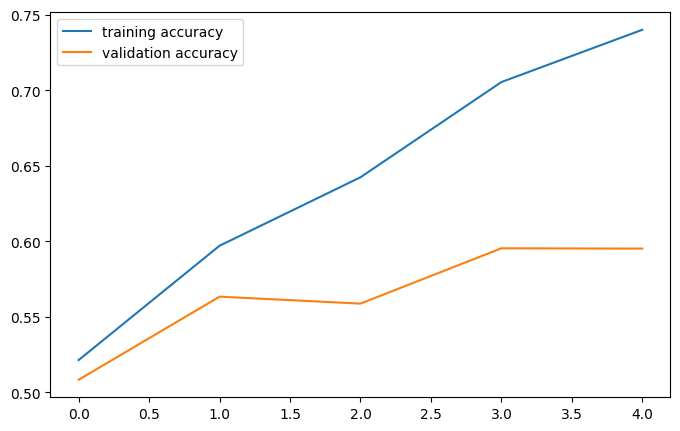

In [10]:
loss , accuracy = model.evaluate(X_test,y_test)
print("loss:",loss)
print("accuracy:",accuracy)

#plot training accuracy and validation accuarcy

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'],label='training accuracy')
plt.plot(history.history['val_accuracy'],label='validation accuracy')
plt.legend()
plt.show()

#plot loss and decode reviews

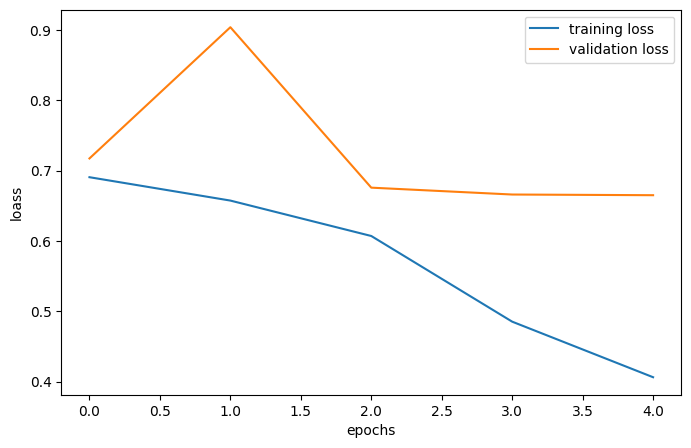

In [11]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'],label='training loss')
plt.plot(history.history['val_loss'],label='validation loss')
plt.xlabel("epochs")
plt.ylabel("loass")
plt.legend()
plt.show()



In [12]:
#reverse dictionary : integer id -->word
word_index = imdb.get_word_index()
reverse_word_index = {v + 3: k for k , v in word_index.items()}
reverse_word_index[0] = '<PAD>'
reverse_word_index[1] = '<START>'
reverse_word_index[2] = '<UNK>'
reverse_word_index[3] = '<UNUSED>'

#dsplay the revie and predict the sentiment


In [13]:
review =" ".join([reverse_word_index.get(i,"?")for i in X_test[0]])
print(review[:1000])

<START> please give this one a miss br br <UNK> <UNK> and the rest of the cast rendered terrible performances the show is flat flat flat br br i don't know how michael madison could have allowed this one on his plate he almost seemed to know this wasn't going to work out and his performance was quite <UNK> so all you madison fans give this a miss <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PA

In [14]:
#predic sentiment for first 5 reviews
prediction = model.predict(X_test[:5])
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step
[[0.4922962 ]
 [0.30543497]
 [0.4255948 ]
 [0.334255  ]
 [0.49254096]]


In [15]:

#convert probablity into class label
for i , value in enumerate(prediction):
  if value >0.5:
    print(f"review {i+1} : positive")
  else:
    print(f"review {i+1}: negative")

review 1: negative
review 2: negative
review 3: negative
review 4: negative
review 5: negative


# =======>QLORA practicals<========

In [16]:
pip install --upgrade transformers datasets accelerate bitsandbytes peft trl

In [1]:
import torch
from transformers import (AutoModelForCausalLM , AutoTokenizer , BitsAndBytesConfig,)

In [17]:
from datasets import load_dataset
from peft import (LoraConfig , prepare_model_for_kbit_training ,)

In [18]:
from trl import SFTTrainer , SFTConfig

#Selecting the base model & dataset

In [19]:
MODEL_NAME ="TinyLlama/TinyLlama-1.1B-Chat-v1.0"
DATASET_NAME ="timdettmers/openassistant-guanaco"

#congiguring the 4 -bit quantization

In [20]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit = True,
    bnb_4bit_quant_type ="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True

)

#loading the quantized model

In [21]:
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME , quantization_config = bnb_config , device_map ="auto")

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.20GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

#prepare the model for k-bit ytaining

In [22]:
model = prepare_model_for_kbit_training(model)

#defining the LORA configuration

In [23]:
peft_config = LoraConfig(r=16 , lora_alpha = 32 , target_modules =["q_proj","v_proj","k_proj","o_proj"],
                         lora_dropout = 0.05,bias = "none",task_type ="CAUSAL_LM")

#Loading the trainign Datset

In [24]:
dataset = load_dataset(DATASET_NAME , split ="train[:1000]")

README.md:   0%|          | 0.00/395 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


openassistant_best_replies_train.jsonl: reconstructing file:   0%|          |  0.00B / 20.9MB            

openassistant_best_replies_train.jsonl: downloading bytes:           |  0.00B            

openassistant_best_replies_eval.jsonl:   0%|          | 0.00/1.11M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9846 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/518 [00:00<?, ? examples/s]

#srtting up the Tokenizer

In [25]:
from transformers import AutoTokenizer

MODEL_NAME = "TinyLlama/TinyLlama-1.1B-chat-v1.0"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B /  500kB            

tokenizer.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

#Configure the training RUn(SFTConfig)

In [26]:
training_args = SFTConfig(output_dir ="./qlora_output",per_device_train_batch_size=2,
                          gradient_accumulation_steps=4,
                          learning_rate=2e-4,
                          logging_steps=10,
                          max_steps=100,
                          fp16=False,
                          bf16=True,
                          optim="paged_adamw_8bit",
                          dataset_text_field ="text")

#building the SFTTrainer


In [27]:
trainer = SFTTrainer(model=model,train_dataset = dataset , peft_config = peft_config,
                     processing_class = tokenizer , args = training_args)

Adding EOS to train dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

#running , trainign and saving the adapter

In [28]:
trainer.train()
trainer.model.save_pretrained("./my_saved_qlora")

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Step,Training Loss
10,1.664553
20,1.572964
30,1.539549
40,1.471087
50,1.547415
60,1.534945
70,1.454788
80,1.573780
90,1.475898
100,1.478400


###Building a RAG chatbot ###

In [1]:
!pip install -q \
langchain \
langchain-community \
langchain-text-splitters \
pypdf \
faiss-cpu \
sentence-transformers \
transformers \
accelerate

#upload & load the PDF

In [2]:
from google.colab import files
from langchain_community.document_loaders\
import PyPDFLoader

In [14]:
uploaded = files.upload()
pdf_file = list(uploaded.keys())[0]

loader = PyPDFLoader(pdf_file)
documents = loader.load()
print("pages:",len(documents))

Saving Introduction to Machine Learning with Python ( PDFDrive.com )-min.pdf to Introduction to Machine Learning with Python ( PDFDrive.com )-min.pdf
pages: 392


#split text into chunks

In [15]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Create the text splitter
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=100
)

# Split the documents into chunks
chunks = text_splitter.split_documents(documents)

# Print the total number of chunks
print("Chunks:", len(chunks))

Chunks: 1885


#Turn chunks into Embeddings

In [16]:
from langchain_community.embeddings import HuggingFaceEmbeddings

# Create the embeddings
embeddings = HuggingFaceEmbeddings(model_name = "Sentence-transformers/all-MiniLM-L6-V2")

/tmp/ipykernel_20314/2417132752.py:4: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name = "Sentence-transformers/all-MiniLM-L6-V2")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

#BUILD THE VECTOE STORE & retriever

In [17]:
from langchain_community.vectorstores import FAISS

In [19]:
vectorstore = FAISS.from_documents(chunks,embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k":3})

#load the language model


In [31]:
from transformers import pipeline

generator = pipeline(task ="text-generation",model ="HuggingFaceTB/SmolLM2-1.7B-Instruct",max_new_tokens=256,device_map ="auto")

Loading weights:   0%|          | 0/218 [00:00<?, ?it/s]

#the ask function - Prompt Engineering

In [32]:
def ask(question):
  docs = retriever.invoke(question)
  context = "\n\n".join([d.page_content for d in docs])
  prompt = f"""answer only using the context.
  if not found , reply :
    "i dont know based on the dicument"
context : {context}
question :{question}
answer :"""
  response = generator(prompt)
  return response[0]["generated_text"]

#testing the chatbot

In [33]:
answer = ask("what is tjis document about?")
print(answer)

questions = ["summarize this document.","who is the author?"]

for q in questions:
  print("question :",q)
  print("answer :",ask(q))


[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


answer only using the context.
  if not found , reply :
    "i dont know based on the dicument"
context : 1 Arguably, the content of websites linked to in tweets contains more information than the text of the tweets
themselves.
2 Most of what we will talk about in the rest of the chapter also applies to other languages that use the Roman
alphabet, and partially to other languages with word boundary delimiters. Chinese, for example, does not
delimit word boundaries, and has other challenges that make applying the techniques in this chapter difficult.

tences. Examples include tweets, chat logs, and hotel reviews, as well as the collected
works of Shakespeare, the content of Wikipedia, or the Project Gutenberg collection
of 50,000 ebooks. All of these collections contain information mostly as sentences
composed of words. 1 For simplicity’s sake, let’s assume all our documents are in one
language, English. 2 In the context of text analysis, the dataset is often called the cor‐

which you 

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


answer : answer only using the context.
  if not found , reply :
    "i dont know based on the dicument"
context : Summary and Outlook                                                                                                   23
iii

While the publisher and the authors have used good faith efforts to ensure that the information and
instructions contained in this work are accurate, the publisher and the authors disclaim all responsibility
for errors or omissions, including without limitation responsibility for damages resulting from the use of
or reliance on this work. Use of the information and instructions contained in this work is at your own

them will not provide you with the full picture. One way to summarize them is the
f-score or f-measure, which is with the harmonic mean of precision and recall:
F = 2 · precision·recall
precision+recall
Evaluation Metrics and Scoring | 283
question :summarize this document.
answer :
question : who is the author?
answer : answer only usin